The Monte Carlo approach to option pricing and hedging is a very useful and easily implemented method. It can be used for numerical evaluation of nearly all derivatives, but has the disadvantage of being computationally slow. In this section we will demonstrate the flexibility of the method by developing algorithms for the pricing of barrier and Asian options, along with more standard options having payoff of the form f(S(T)). In addition, we shall address the questions of hedging and numerical efficiency of the Monte Carlo
technique. 

The idea behind the Monte Carlo technique is rather simple: let us assume that we would like to calculate the expectation $\mathbb{E}[g(Y)]$, where $g$ is some known function and $Y$ is a random variable. Imagine we have a recipe for simulating independent outcomes from $Y$ on a computer. Then we can draw $N$ independent outcomes $(y_1, \dots, y_N)$ from $Y$ and calculate the average $\frac{1}{N} \sum_{i=1}^N g(y_i)$. This number will be an approximation of the expectation $\mathbb{E}[g(Y)]$, i.e.,

$$\mathbb{E}[g(Y)] \approx \frac{1}{N} \sum_{i=1}^N g(y_i)$$

# 1. Monte Carlo pricing of a claim X=f(S_T)*

$$C(t,x) = e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}[f(S_{t,x}(T))],$$

and specialize it at $t = 0, x = S_0$:

$$C(0,S_0) = e^{-rT} \mathbb{E}^{\mathbb{Q}}[f(S_{0,S_0}(T))].$$

For the first experiment, we'll use a European call because we know its exact Black–Scholes price and can therefore measure the Monte Carlo error.

Under the risk-neutral measure $\mathbb{Q}$, the stock follows

$$dS_t = r S_t dt + \sigma S_t dW_t.$$

The exact solution starting from $S_0 = x$ at $t = 0$ is

$$S_{0,x}(T) = x \exp \left( \left( r - \frac{1}{2}\sigma^2 \right) T + \sigma W_T \right).$$

Since

$$W_T = \sqrt{T} Z, \quad Z \sim \mathcal{N}(0,1),$$

we can simulate the terminal stock prices directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Model and option parameters

S0 = 100.0       # Initial stock price
K = 100.0        # Strike price
r = 0.05         # Risk-free interest rate
sigma = 0.20     # Volatility
T = 1.0          # Time to maturity

# Number of Monte Carlo simulations
N = 100_000
def simulate_terminal_stock(S0, r, sigma, T, N):
    """
    Simulate S^{0,S0}(T) under the risk-neutral measure Q.
    """
    Z = np.random.normal(0, 1, N)

    ST = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    return ST
def call_payoff(ST, K):
    return np.maximum(ST - K, 0.0)

Our theoretical formula is

$$C(0,S_0) = e^{-rT} \mathbb{E}^{\mathbb{Q}}[f(S_T)].$$

Monte Carlo replaces the expectation by a sample average:

$$\hat{C}_N = e^{-rT} \frac{1}{N} \sum_{i=1}^N f(S_T^{(i)}).$$

In [2]:
def monte_carlo_price(S0, K, r, sigma, T, N):
    """
    Monte Carlo estimate of

        C(0,S0) = exp(-rT) E_Q[f(ST)]

    for a European call.
    """

    ST = simulate_terminal_stock(S0, r, sigma, T, N)

    payoffs = call_payoff(ST, K)

    price = np.exp(-r * T) * np.mean(payoffs)

    return price, payoffs, ST
price_mc, payoffs, ST = monte_carlo_price(
    S0, K, r, sigma, T, N
)

print(f"Monte Carlo price: {price_mc:.6f}")

Monte Carlo price: 10.396726


Since we are using a European call, we can compare the Monte Carlo estimate with the analytical Black–Scholes formula.

$$C_{\text{BS}} = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2),$$

where

$$d_1 = \frac{\ln(S_0/K) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma \sqrt{T}},$$

and

$$d_2 = d_1 - \sigma \sqrt{T}.$$

In [3]:
def black_scholes_call(S0, K, r, sigma, T):
    """
    Analytical Black-Scholes price of a European call.
    """

    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    price = (
        S0 * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return price
price_bs = black_scholes_call(
    S0, K, r, sigma, T
)

print(f"Black-Scholes price: {price_bs:.6f}")
print(f"Monte Carlo price:   {price_mc:.6f}")
print(f"Absolute error:      {abs(price_mc - price_bs):.6f}")

Black-Scholes price: 10.450584
Monte Carlo price:   10.396726
Absolute error:      0.053857


This gives us a very important first validation:

$$\hat{C}_N \longrightarrow C_{\text{BS}} \quad \text{as } N \to \infty.$$

# 2. Accuracy of the Monte Carlo Method

Having constructed the Monte Carlo estimator in the previous section, we now
turn to an important question: **how accurate is our estimate?**

For $N$ simulated paths, our estimator is

$$
\widehat{C}_N
=
e^{-rT}
\frac{1}{N}
\sum_{i=1}^{N}
f\left(S_T^{(i)}\right).
$$

Although $\widehat{C}_N$ converges to the true price as $N$ increases, the
estimate obtained from a finite number of simulations is itself a random
variable. Running the same algorithm twice with different random numbers will
generally produce different prices.

The purpose of this section is therefore to understand the magnitude of these
random deviations and how they depend on $N$.

## 2.1 Central Limit Theorem

Let

$$
Y_i =
e^{-rT}f\left(S_T^{(i)}\right),
$$

where the $Y_i$ are independent and identically distributed. Then our
Monte Carlo estimator can simply be written as

$$
\widehat{C}_N
=
\frac{1}{N}
\sum_{i=1}^{N}Y_i.
$$

Moreover,

$$
\mathbb{E}_{\mathbb Q}[Y_i]
=
C(0,S_0).
$$

Assuming that $Y_i$ has finite variance, the Central Limit Theorem gives

$$
\sqrt{N}
\left(
\widehat{C}_N-C(0,S_0)
\right)
\xrightarrow[]{d}
\mathcal{N}
\left(
0,\operatorname{Var}(Y)
\right).
$$

Therefore, for large $N$, we can approximately view the Monte Carlo estimator
as a normal random variable:

$$
\boxed{
\widehat{C}_N
\approx
\mathcal{N}
\left(
C(0,S_0),
\frac{\operatorname{Var}(Y)}{N}
\right).
}
$$

Consequently, its standard deviation is

$$
\boxed{
\operatorname{Std}(\widehat{C}_N)
=
\frac{\operatorname{Std}(Y)}{\sqrt{N}}.
}
$$

This immediately gives the convergence rate of the Monte Carlo method:

$$
\boxed{
\operatorname{Std}(\widehat{C}_N)
=
O\left(\frac{1}{\sqrt{N}}\right).
}
$$

Thus, increasing the number of simulations does improve the accuracy, but
only at a relatively slow rate.

For example, to reduce the standard deviation by a factor of $2$, we need to
multiply the number of simulations by $4$:

$$
\frac{1}{\sqrt{4N}}
=
\frac{1}{2\sqrt{N}}.
$$

This slow convergence will be the main motivation for the variance reduction
techniques considered later.

## 2.2 The stochastic nature of the error

An important point is that the Monte Carlo error is **random**.

Let

$$
\sigma_Y = \operatorname{Std}(Y).
$$

For large $N$,

$$
\frac{
\widehat{C}_N-C(0,S_0)
}{
\sigma_Y/\sqrt{N}
}
\approx
\mathcal{N}(0,1).
$$

Therefore,

$$
\mathbb{P}
\left(
\left|
\widehat{C}_N-C(0,S_0)
\right|
\leq
\frac{\sigma_Y}{\sqrt{N}}
\right)
\approx 68.3\%.
$$

Similarly,

$$
\mathbb{P}
\left(
\left|
\widehat{C}_N-C(0,S_0)
\right|
\leq
2\frac{\sigma_Y}{\sqrt{N}}
\right)
\approx 95.4\%.
$$

Hence, we cannot say that a Monte Carlo estimate is always within a fixed
error of the true price. Instead, we can only make probabilistic statements
about the size of the error.

This also explains why two Monte Carlo simulations using the same number of
paths can give different prices.

## 2.3 Estimating the standard error

The quantity

$$
\sigma_Y=\operatorname{Std}(Y)
$$

is generally unknown. In fact, calculating it exactly would require computing
another expectation, which is often as difficult as the original pricing
problem.

We therefore estimate it from the simulated values.

Recall that the previous section already produced the discounted payoffs

$$
Y_1,\ldots,Y_N.
$$

Their sample standard deviation is

$$
s_N
=
\sqrt{
\frac{1}{N-1}
\sum_{i=1}^{N}
(Y_i-\widehat{C}_N)^2
}.
$$

We can therefore estimate the standard deviation of the Monte Carlo estimator
by

$$
\boxed{
\widehat{SE}_N
=
\frac{s_N}{\sqrt{N}}.
}
$$

This quantity is called the **Monte Carlo standard error**.

For sufficiently large $N$, we can consequently construct an approximate
$95\%$ confidence interval:

$$
\boxed{
\widehat{C}_N
\pm
1.96\,\widehat{SE}_N.
}
$$

We now compute this standard error using the simulated discounted payoffs
from Section 1.

In [4]:
# Estimate the standard error from the discounted payoffs

discounted_payoffs = np.exp(-r * T) * payoffs

std_payoff = np.std(discounted_payoffs, ddof=1)

standard_error = std_payoff / np.sqrt(N)

print(f"Monte Carlo price: {price_mc:.6f}")
print(f"Standard error:    {standard_error:.6f}")

Monte Carlo price: 10.396726
Standard error:    0.046561


In [5]:
# 95% confidence interval

lower = price_mc - 1.96 * standard_error
upper = price_mc + 1.96 * standard_error

print(f"95% confidence interval: [{lower:.6f}, {upper:.6f}]")
print(f"Black-Scholes price:      {price_bs:.6f}")

95% confidence interval: [10.305468, 10.487985]
Black-Scholes price:      10.450584


## 2.4 Numerical experiment: convergence with $N$

We now investigate numerically the convergence predicted by the Central Limit
Theorem.

We repeat the Monte Carlo pricing procedure for different numbers of
simulated paths and compare the resulting prices with the exact
Black--Scholes price computed in Section 1.

Because the Monte Carlo estimate is random, the observed error will fluctuate
from one simulation to another. Nevertheless, as $N$ increases, the magnitude
of these fluctuations should decrease approximately as

$$
\frac{1}{\sqrt{N}}.
$$

We measure the relative error by

$$
\text{Relative error}
=
\frac{
\widehat{C}_N-C_{\mathrm{BS}}
}{
C_{\mathrm{BS}}
}.
$$

In [9]:
N_values = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]

prices = []
relative_errors = []
standard_errors = []

for N_i in N_values:

    price_i, payoffs_i, _ = monte_carlo_price(
        S0, K, r, sigma, T, N_i
    )

    discounted_payoffs_i = np.exp(-r * T) * payoffs_i

    se_i = (
        np.std(discounted_payoffs_i, ddof=1)
        / np.sqrt(N_i)
    )

    relative_error_i = (
        (price_i - price_bs) / price_bs
    )

    prices.append(price_i)
    relative_errors.append(relative_error_i)
    standard_errors.append(se_i)

    print(
        f"N = {N_i:>8,} | "
        f"Price = {price_i:.5f} | "
        f"Relative error = {100*relative_error_i:.2f}% | "
        f"SE = {se_i:.5f}"
    )

N =      100 | Price = 12.86132 | Relative error = 23.07% | SE = 1.52039
N =    1,000 | Price = 10.64939 | Relative error = 1.90% | SE = 0.44912
N =   10,000 | Price = 10.40462 | Relative error = -0.44% | SE = 0.14734
N =  100,000 | Price = 10.39367 | Relative error = -0.54% | SE = 0.04649
N = 1,000,000 | Price = 10.45759 | Relative error = 0.07% | SE = 0.01475
N = 10,000,000 | Price = 10.44894 | Relative error = -0.02% | SE = 0.00465


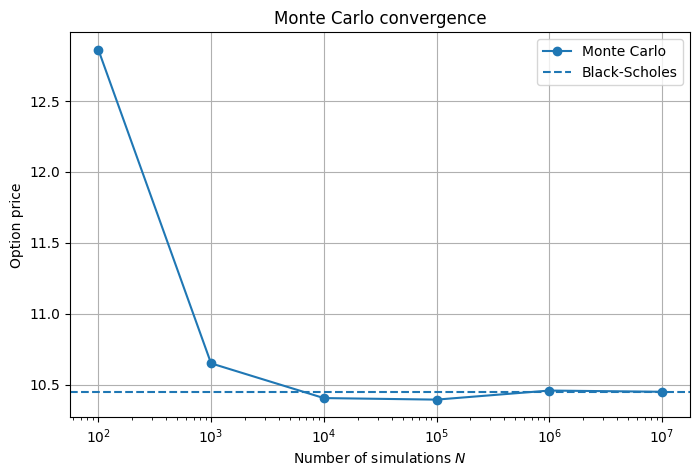

In [10]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    N_values,
    prices,
    marker="o",
    label="Monte Carlo"
)

plt.axhline(
    price_bs,
    linestyle="--",
    label="Black-Scholes"
)

plt.xlabel("Number of simulations $N$")
plt.ylabel("Option price")
plt.title("Monte Carlo convergence")
plt.legend()
plt.grid(True)

plt.show()

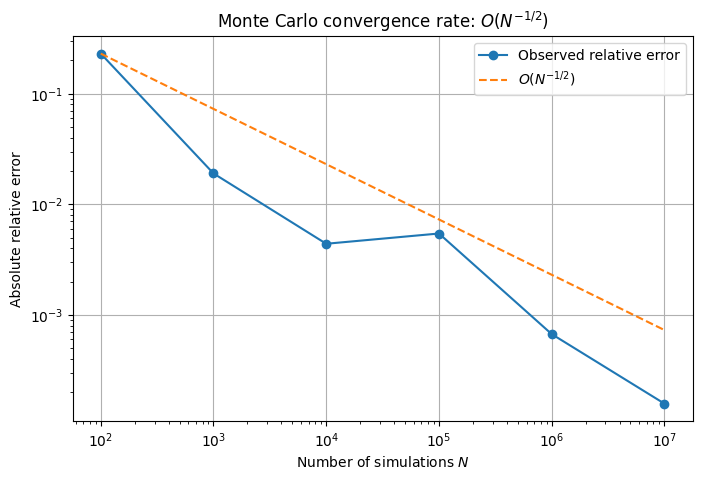

In [11]:
plt.figure(figsize=(8, 5))

plt.loglog(
    N_values,
    np.abs(relative_errors),
    marker="o",
    label="Observed relative error"
)

# Reference O(1/sqrt(N)) curve
reference = (
    np.abs(relative_errors[0])
    * np.sqrt(N_values[0] / np.array(N_values))
)

plt.loglog(
    N_values,
    reference,
    linestyle="--",
    label=r"$O(N^{-1/2})$"
)

plt.xlabel("Number of simulations $N$")
plt.ylabel("Absolute relative error")
plt.title(r"Monte Carlo convergence rate: $O(N^{-1/2})$")
plt.legend()
plt.grid(True)

plt.show()

## 2.5 Conclusion

The numerical experiment confirms the theoretical result obtained from the
Central Limit Theorem. Increasing the number of simulated paths makes the
Monte Carlo estimator more stable and brings it closer to the true
Black--Scholes price.

However, the convergence is slow:

$$
\boxed{
\text{error}=O\left(\frac{1}{\sqrt N}\right).
}
$$

Consequently, simply increasing the number of simulations can become
computationally expensive. For example, reducing the statistical error by a
factor of $2$ requires approximately $4$ times as many simulated paths.

This motivates the central question of the next section:

> **Can we reduce the variance of the Monte Carlo estimator without simply
> increasing the number of simulations?**

This is the objective of **variance reduction techniques**.

# 3. Variance Reduction: Antithetic Variates

The previous section showed that the Monte Carlo estimator converges at the
relatively slow rate

$$
O\left(\frac{1}{\sqrt{N}}\right).
$$

Increasing $N$ is therefore an inefficient way of obtaining higher accuracy.
We now investigate whether we can reduce the variance of the estimator while
keeping approximately the same number of simulations.

The first variance reduction technique we consider is the **antithetic
variates method**.

## 3.1 Idea behind antithetic variates

Recall that under the risk-neutral measure,

$$
S_T
=
S_0
\exp\left(
\left(r-\frac12\sigma^2\right)T
+
\sigma\sqrt{T}Z
\right),
$$

where

$$
Z\sim\mathcal N(0,1).
$$

In the standard Monte Carlo method, we generate independent values

$$
Z_1,\ldots,Z_N
$$

and calculate the corresponding payoffs.

The idea of antithetic variates is very simple: whenever we generate a
standard normal variable $Z_i$, we also use its opposite $-Z_i$.

Thus, from one random draw $Z_i$, we construct two stock prices:

$$
S_T^{(i,+)}
=
S_0
\exp\left(
\left(r-\frac12\sigma^2\right)T
+
\sigma\sqrt{T}Z_i
\right),
$$

and

$$
S_T^{(i,-)}
=
S_0
\exp\left(
\left(r-\frac12\sigma^2\right)T
-
\sigma\sqrt{T}Z_i
\right).
$$

The corresponding discounted payoffs are

$$
Y_i^{(+)}
=
e^{-rT}f(S_T^{(i,+)}),
$$

and

$$
Y_i^{(-)}
=
e^{-rT}f(S_T^{(i,-)}).
$$

Instead of using the two observations separately, we average them:

$$
\boxed{
\widetilde Y_i
=
\frac12
\left(
Y_i^{(+)}+Y_i^{(-)}
\right).
}
$$

The antithetic Monte Carlo estimator is then

$$
\boxed{
\widehat C_N^{\mathrm{AV}}
=
\frac1N
\sum_{i=1}^N
\widetilde Y_i.
}
$$

Notice that this estimator still has the correct expectation. Indeed,

$$
\mathbb E[\widetilde Y_i]
=
\frac12
\left(
\mathbb E[Y_i^{(+)}]
+
\mathbb E[Y_i^{(-)}]
\right).
$$

Since $Z$ and $-Z$ have exactly the same $\mathcal N(0,1)$ distribution,

$$
\mathbb E[Y_i^{(+)}]
=
\mathbb E[Y_i^{(-)}]
=
C(0,S_0).
$$

Therefore,

$$
\boxed{
\mathbb E[\widetilde Y_i]
=
C(0,S_0).
}
$$

Thus, antithetic variates do **not** introduce a bias into the Monte Carlo
estimator. The objective is only to reduce its variance.

## 3.2 Why does this reduce the variance?

The key observation is that $Z_i$ and $-Z_i$ are perfectly negatively
correlated:

$$
\operatorname{Corr}(Z_i,-Z_i)=-1.
$$

For a call option, a large positive value of $Z_i$ tends to produce a large
stock price and therefore a large payoff. At the same time, $-Z_i$ produces a
smaller stock price and therefore tends to produce a smaller payoff.

Hence, the two payoffs tend to move in opposite directions.

Let

$$
Y^+=e^{-rT}f(S_T(Z)),
\qquad
Y^-=e^{-rT}f(S_T(-Z)).
$$

Then

$$
\operatorname{Var}
\left(
\frac{Y^++Y^-}{2}
\right)
=
\frac14
\left[
\operatorname{Var}(Y^+)
+
\operatorname{Var}(Y^-)
+
2\operatorname{Cov}(Y^+,Y^-)
\right].
$$

Since $Y^+$ and $Y^-$ have the same distribution,

$$
\operatorname{Var}(Y^+)
=
\operatorname{Var}(Y^-)
=
\sigma_Y^2.
$$

Therefore,

$$
\operatorname{Var}(\widetilde Y)
=
\frac12
\left(
\sigma_Y^2
+
\operatorname{Cov}(Y^+,Y^-)
\right).
$$

For antithetic variates, we expect

$$
\operatorname{Cov}(Y^+,Y^-)<0.
$$

Consequently,

$$
\boxed{
\operatorname{Var}(\widetilde Y)
<
\operatorname{Var}(Y).
}
$$

This is the fundamental reason why the method works.

The important point is that we are not changing the number of random normal
variables generated. Instead, each random variable is used twice, in a
positively and negatively perturbed version, in order to obtain two negatively
correlated payoffs.

## 3.3 Application to a European call

We now apply the antithetic variates method to the same European call option
used in the previous sections.

The payoff is

$$
f(S_T)=(S_T-K)^+.
$$

For each simulated value $Z_i$, we construct

$$
S_T^{(i,+)}
=
S_0
\exp\left(
\left(r-\frac12\sigma^2\right)T
+
\sigma\sqrt{T}Z_i
\right)
$$

and

$$
S_T^{(i,-)}
=
S_0
\exp\left(
\left(r-\frac12\sigma^2\right)T
-
\sigma\sqrt{T}Z_i
\right).
$$

The two corresponding discounted call payoffs are

$$
Y_i^{(+)}
=
e^{-rT}
\left(S_T^{(i,+)}-K\right)^+
$$

and

$$
Y_i^{(-)}
=
e^{-rT}
\left(S_T^{(i,-)}-K\right)^+.
$$

Our estimator becomes

$$
\boxed{
\widehat C_N^{\mathrm{AV}}
=
\frac{e^{-rT}}{2N}
\sum_{i=1}^N
\left[
\left(S_T^{(i,+)}-K\right)^+
+
\left(S_T^{(i,-)}-K\right)^+
\right].
}
$$

We can now compare this estimator with the crude Monte Carlo estimator from
Section 2.

In [12]:
# Antithetic variates Monte Carlo pricing

def antithetic_call_price(S0, K, r, sigma, T, N):
    """
    Monte Carlo pricing of a European call using
    antithetic variates.
    
    N = number of original normal draws.
    Each draw generates two stock prices: Z and -Z.
    """

    # Generate N independent standard normal variables
    Z = np.random.normal(0, 1, N)

    # Antithetic normal variables
    Z_antithetic = -Z

    # Stock prices corresponding to Z
    ST_plus = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    # Stock prices corresponding to -Z
    ST_minus = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z_antithetic
    )

    # Discounted payoffs
    payoff_plus = np.exp(-r * T) * np.maximum(ST_plus - K, 0)
    payoff_minus = np.exp(-r * T) * np.maximum(ST_minus - K, 0)

    # Pairwise average
    antithetic_payoffs = 0.5 * (
        payoff_plus + payoff_minus
    )

    # Monte Carlo estimator
    price = np.mean(antithetic_payoffs)

    # Estimated standard error
    standard_error = (
        np.std(antithetic_payoffs, ddof=1)
        / np.sqrt(N)
    )

    return price, standard_error, antithetic_payoffs

In [13]:
price_av, se_av, av_payoffs = antithetic_call_price(
    S0, K, r, sigma, T, N
)

print(f"Black-Scholes price:       {price_bs:.6f}")
print(f"Crude MC price:            {price_mc:.6f}")
print(f"Antithetic MC price:       {price_av:.6f}")
print(f"Crude MC standard error:   {standard_error:.6f}")
print(f"Antithetic standard error: {se_av:.6f}")

Black-Scholes price:       10.450584
Crude MC price:            10.396726
Antithetic MC price:       10.460398
Crude MC standard error:   0.046561
Antithetic standard error: 0.023383


In [14]:
# Compare the estimated variances

crude_variance = np.var(
    discounted_payoffs,
    ddof=1
)

antithetic_variance = np.var(
    av_payoffs,
    ddof=1
)

print(f"Crude MC variance:      {crude_variance:.6f}")
print(f"Antithetic variance:    {antithetic_variance:.6f}")

variance_reduction = (
    1 - antithetic_variance / crude_variance
)

print(
    f"Variance reduction:     "
    f"{100 * variance_reduction:.2f}%"
)

Crude MC variance:      216.789167
Antithetic variance:    54.675117
Variance reduction:     74.78%


In [16]:
N_values = [100, 1_000, 10_000, 100_000, 1_000_000]

crude_se = []
antithetic_se = []

for N_i in N_values:

    # Crude Monte Carlo
    price_i, payoffs_i, _ = monte_carlo_price(
        S0, K, r, sigma, T, N_i
    )

    discounted_i = np.exp(-r * T) * payoffs_i

    se_crude_i = (
        np.std(discounted_i, ddof=1)
        / np.sqrt(N_i)
    )

    # Antithetic Monte Carlo
    _, se_av_i, _ = antithetic_call_price(
        S0, K, r, sigma, T, N_i
    )

    crude_se.append(se_crude_i)
    antithetic_se.append(se_av_i)

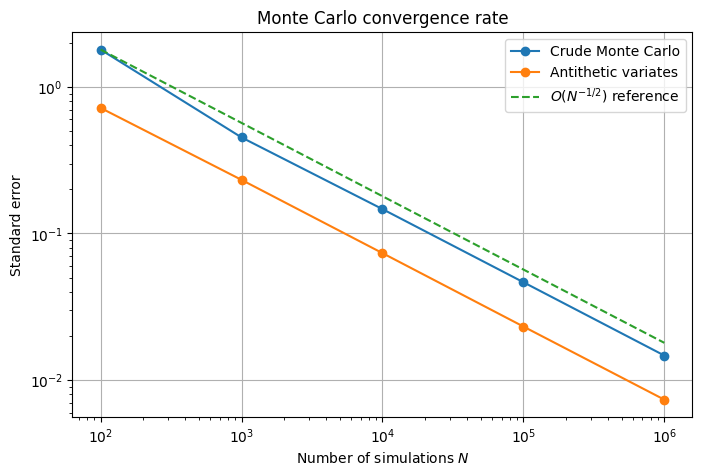

In [19]:
plt.figure(figsize=(8, 5))

plt.loglog(
    N_values,
    crude_se,
    marker="o",
    label="Crude Monte Carlo"
)

plt.loglog(
    N_values,
    antithetic_se,
    marker="o",
    label="Antithetic variates"
)

# Reference O(1/sqrt(N)) curve
reference = 1 / np.sqrt(np.array(N_values))

# Scale it so that it is comparable to the standard errors
reference = reference * crude_se[0] / reference[0]

plt.loglog(
    N_values,
    reference,
    linestyle="--",
    label=r"$O(N^{-1/2})$ reference"
)

plt.xlabel("Number of simulations $N$")
plt.ylabel("Standard error")
plt.title("Monte Carlo convergence rate")
plt.legend()
plt.grid(True)

plt.show()

The two curves should exhibit the same asymptotic behavior,

$$\mathcal{O}(N^{-1/2}),$$

because antithetic variates do not change the fundamental Monte Carlo convergence rate. Instead, they reduce the constant multiplying $N^{-1/2}$.

In other words,

$$\operatorname{SE}_{\text{crude}} \approx \frac{c_1}{\sqrt{N}},$$

while

$$\operatorname{SE}_{\text{AV}} \approx \frac{c_2}{\sqrt{N}},$$

with $c_2 < c_1$.

Thus, antithetic variates do not make Monte Carlo converge at a theoretically faster rate. They make it more efficient at the same convergence rate.

This provides our first example of variance reduction: rather than simply increasing the number of simulated paths, we exploit the structure of the random variables already being generated to obtain a more precise estimator.

# 4. Path-Dependent Options: Knock-Out Options

The Monte Carlo method developed in the previous sections can be applied
directly to claims of the form

$$
X=f(S_T),
$$

because in that case only the terminal stock price $S_T$ is needed.

For **path-dependent claims**, however, the payoff depends on the evolution
of the stock price throughout the lifetime of the contract. We therefore need
to simulate the stock price at several time points between $0$ and $T$.

In this section we consider a **down-and-out-style knock-out call**, more
precisely a call option that is knocked out when the stock price rises above
a prescribed upper barrier $B$.

The payoff is

$$
X
=
(S_T-K)^+
\mathbf{1}_{\{\max_{0\leq t\leq T}S_t<B\}},
$$

where

- $K$ is the strike price,
- $B$ is the barrier,
- $T$ is the maturity.

Thus,

$$
X=
\begin{cases}
(S_T-K)^+, & \text{if } S_t<B \text{ for all }t\in[0,T],\\
0, & \text{otherwise}.
\end{cases}
$$

Under the risk-neutral measure $\mathbb Q$, the price at time $0$ is

$$
\boxed{
P(0)
=
e^{-rT}
\mathbb E_{\mathbb Q}
\left[
(S_T-K)^+
\mathbf{1}_{\{\max_{0\leq t\leq T}S_t<B\}}
\right].
}
$$

Unlike a European call, we cannot determine the payoff by knowing only
$S_T$. We must determine whether the barrier was crossed at some point
during the lifetime of the option.

## 5.1 Discretizing the Stock Path

Under the risk-neutral measure,

$$
dS_t=rS_t\,dt+\sigma S_t\,dW_t.
$$

The exact solution over a time interval $[t_{j-1},t_j]$ is

$$
S_{t_j}
=
S_{t_{j-1}}
\exp\left(
\left(r-\frac12\sigma^2\right)\Delta t
+
\sigma\left(W_{t_j}-W_{t_{j-1}}\right)
\right),
$$

where

$$
\Delta t=\frac{T}{M}.
$$

Since

$$
W_{t_j}-W_{t_{j-1}}
=
\sqrt{\Delta t}\,Z_j,
\qquad
Z_j\sim\mathcal N(0,1),
$$

we obtain the recursion

$$
\boxed{
S_{t_j}
=
S_{t_{j-1}}
\exp\left(
\left(r-\frac12\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}\,Z_j
\right).
}
$$

The random variables $Z_1,\ldots,Z_M$ are independent standard normal
random variables.

We therefore simulate the stock path at

$$
0=t_0<t_1<\cdots<t_M=T.
$$

The barrier condition is approximated by checking

$$
S_{t_j}<B,
\qquad j=1,\ldots,M.
$$

This introduces a **discretization error**: the continuous stock process could
cross the barrier between two consecutive monitoring dates without being
detected. Increasing $M$ makes the monitoring grid finer and reduces this
error.

## 5.2 Crude Monte Carlo

For each simulated path, we recursively generate

$$
S_{t_1},S_{t_2},\ldots,S_{t_M}.
$$

If at least one simulated value satisfies

$$
S_{t_j}\geq B,
$$

the option is knocked out and the payoff is zero.

Otherwise, the payoff is

$$
(S_T-K)^+.
$$

Thus, for a simulated path $i$,

$$
X_i
=
(S_T^{(i)}-K)^+
\mathbf 1_{\{\max_j S_{t_j}^{(i)}<B\}}.
$$

The Monte Carlo estimator is therefore

$$
\boxed{
\widehat P_N^{\mathrm{MC}}
=
\frac{e^{-rT}}{N}
\sum_{i=1}^N X_i.
}
$$

### Algorithm 3 — Monte Carlo algorithm for a knock-out option

**For $i=1,\ldots,N$:**

1. Set $S_0^{(i)}=S_0$.

2. For $j=1,\ldots,M$:

   - Draw one outcome

   $$
   Y_j^{(i)}\sim\mathcal N(0,1).
   $$

   - Calculate

   $$
   S_{t_j}^{(i)}
   =
   S_{t_{j-1}}^{(i)}
   \exp\left(
   \left(r-\frac12\sigma^2\right)\Delta t
   +
   \sigma\sqrt{\Delta t}\,Y_j^{(i)}
   \right).
   $$

   - If $S_{t_j}^{(i)}\geq B$, set $X^{(i)}=0$ and proceed to the next
     simulation.

3. If the barrier has not been crossed, set

   $$
   X^{(i)}
   =
   \max(S_T^{(i)}-K,0).
   $$

**After all $N$ simulations:**

4. Calculate

$$
\boxed{
\widehat P_N
=
e^{-rT}\frac1N\sum_{i=1}^N X^{(i)}.
}
$$

In [20]:
def knockout_payoff_path(
    S0, K, B, r, sigma, T, M, Z
):
    """
    Simulate one discretized stock path and compute
    the payoff of an upper-barrier knock-out call.
    """

    dt = T / M

    S = S0

    for z in Z:
        S *= np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * z
        )

        # Barrier is crossed
        if S >= B:
            return 0.0

    # Barrier was never crossed
    return max(S - K, 0.0)

In [21]:
def mc_knockout_price(
    S0, K, B, r, sigma, T, M, N, seed=None
):
    """
    Crude Monte Carlo pricing of an upper-barrier
    knock-out call.
    """

    rng = np.random.default_rng(seed)

    dt = T / M

    # Generate all random numbers at once
    Z = rng.normal(0, 1, size=(N, M))

    payoffs = np.zeros(N)

    for i in range(N):

        S = S0
        knocked_out = False

        for z in Z[i]:

            S *= np.exp(
                (r - 0.5 * sigma**2) * dt
                + sigma * np.sqrt(dt) * z
            )

            if S >= B:
                knocked_out = True
                break

        if not knocked_out:
            payoffs[i] = max(S - K, 0.0)

    discounted_payoffs = np.exp(-r * T) * payoffs

    price = np.mean(discounted_payoffs)

    standard_error = (
        np.std(discounted_payoffs, ddof=1)
        / np.sqrt(N)
    )

    return price, standard_error, payoffs

In [22]:
# Knock-out parameters

B = 130.0       # Upper barrier
M = 252         # Daily monitoring over one year
N = 100_000

price_ko, se_ko, ko_payoffs = mc_knockout_price(
    S0, K, B, r, sigma, T, M, N, seed=123
)

print(f"Knock-out MC price: {price_ko:.6f}")
print(f"Standard error:     {se_ko:.6f}")

Knock-out MC price: 3.563116
Standard error:     0.020101


## 5.3 Antithetic Variates

We now apply the first variance reduction technique introduced previously:
**antithetic variates**.

For each simulated path generated using

$$
Z_1,\ldots,Z_M,
$$

we construct a second path using

$$
-Z_1,\ldots,-Z_M.
$$

The two paths are therefore

$$
S_{t_j}^{(+)}
=
S_{t_{j-1}}^{(+)}
\exp\left(
\left(r-\frac12\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}Z_j
\right)
$$

and

$$
S_{t_j}^{(-)}
=
S_{t_{j-1}}^{(-)}
\exp\left(
\left(r-\frac12\sigma^2\right)\Delta t
-
\sigma\sqrt{\Delta t}Z_j
\right).
$$

We calculate the two knock-out payoffs,

$$
X_i^{(+)}
\quad\text{and}\quad
X_i^{(-)},
$$

and use their average

$$
\boxed{
\widetilde X_i
=
\frac12
\left(
X_i^{(+)}+X_i^{(-)}
\right).
}
$$

The antithetic estimator is

$$
\boxed{
\widehat P_N^{\mathrm{AV}}
=
\frac{e^{-rT}}{N}
\sum_{i=1}^N
\widetilde X_i.
}
$$

The estimator remains unbiased because $Z$ and $-Z$ have the same
distribution.

The main objective is again to exploit the negative dependence between the
two paths to reduce the variance of the estimator.

In [23]:
def mc_knockout_antithetic(
    S0, K, B, r, sigma, T, M, N, seed=None
):
    """
    Antithetic variates Monte Carlo pricing
    for an upper-barrier knock-out call.
    """

    rng = np.random.default_rng(seed)

    dt = T / M

    # Only N sets of random numbers are required.
    # Each generates two paths: Z and -Z.
    Z = rng.normal(0, 1, size=(N, M))

    antithetic_payoffs = np.zeros(N)

    for i in range(N):

        S_plus = S0
        S_minus = S0

        knocked_plus = False
        knocked_minus = False

        for z in Z[i]:

            if not knocked_plus:
                S_plus *= np.exp(
                    (r - 0.5 * sigma**2) * dt
                    + sigma * np.sqrt(dt) * z
                )

                if S_plus >= B:
                    knocked_plus = True

            if not knocked_minus:
                S_minus *= np.exp(
                    (r - 0.5 * sigma**2) * dt
                    - sigma * np.sqrt(dt) * z
                )

                if S_minus >= B:
                    knocked_minus = True

        payoff_plus = (
            0.0
            if knocked_plus
            else max(S_plus - K, 0.0)
        )

        payoff_minus = (
            0.0
            if knocked_minus
            else max(S_minus - K, 0.0)
        )

        # Antithetic pair
        antithetic_payoffs[i] = (
            payoff_plus + payoff_minus
        ) / 2

    discounted = np.exp(-r * T) * antithetic_payoffs

    price = np.mean(discounted)

    standard_error = (
        np.std(discounted, ddof=1)
        / np.sqrt(N)
    )

    return price, standard_error, antithetic_payoffs

In [24]:
price_av, se_av, av_payoffs = mc_knockout_antithetic(
    S0, K, B, r, sigma, T, M, N, seed=123
)

print(f"Crude MC price:       {price_ko:.6f}")
print(f"Crude MC SE:          {se_ko:.6f}")
print()
print(f"Antithetic MC price:  {price_av:.6f}")
print(f"Antithetic MC SE:     {se_av:.6f}")

Crude MC price:       3.563116
Crude MC SE:          0.020101

Antithetic MC price:  3.553818
Antithetic MC SE:     0.011897


## 5.4 Control Variates

Antithetic variates reduce variance by introducing negatively correlated
payoffs. We now consider another variance reduction technique:
**control variates**.

The basic idea is to use another random variable whose expectation is known
exactly and which is strongly correlated with the quantity we want to
estimate.

Suppose that $X$ is the knock-out payoff and that $Y$ is another random
variable such that

$$
\mathbb E[Y]
$$

is known.

For any constant $\beta$,

$$
\mathbb E[X-\beta(Y-\mathbb E[Y])]
=
\mathbb E[X].
$$

Therefore, we can construct the estimator

$$
\boxed{
\widehat P_{\mathrm{CV}}
=
e^{-rT}
\frac1N
\sum_{i=1}^N
\left[
X_i
-
\beta
\left(
Y_i-\mathbb E[Y]
\right)
\right].
}
$$

The expectation is unchanged because

$$
\mathbb E[Y-\mathbb E[Y]]=0.
$$

The choice of $\beta$ determines how much the variance is reduced.

For our knock-out call, a natural control variate is the payoff of a
**European call with the same strike and maturity**,

$$
Y=(S_T-K)^+.
$$

This is a particularly convenient choice because its discounted expectation
is known from the Black--Scholes formula:

$$
e^{-rT}\mathbb E_{\mathbb Q}[Y]
=
C_{\mathrm{BS}}.
$$

The knock-out call and the vanilla call are strongly related. In fact,

$$
X
=
(S_T-K)^+
\mathbf 1_{\{\text{barrier not crossed}\}},
$$

while

$$
Y=(S_T-K)^+.
$$

They therefore share the same terminal call payoff, with the knock-out claim
only setting it to zero when the barrier has been crossed.

We consequently expect a significant correlation between $X$ and $Y$.

For convenience, define the discounted variables

$$
X^d=e^{-rT}X,
\qquad
Y^d=e^{-rT}Y.
$$

Then the control variate estimator becomes

$$
\boxed{
\widehat P_{\mathrm{CV}}
=
\frac1N
\sum_{i=1}^N
\left[
X_i^d
-
\beta
\left(
Y_i^d-C_{\mathrm{BS}}
\right)
\right].
}
$$

The optimal value of $\beta$ is

$$
\boxed{
\beta^*
=
\frac{\operatorname{Cov}(X^d,Y^d)}
{\operatorname{Var}(Y^d)}.
}
$$

In practice, the covariance and variance are unknown, so we estimate
$\beta^*$ from the simulated sample:

$$
\boxed{
\widehat\beta
=
\frac{\widehat{\operatorname{Cov}}(X^d,Y^d)}
{\widehat{\operatorname{Var}}(Y^d)}.
}
$$

This is the value that we will use in the numerical experiment.

In [25]:
def mc_knockout_control_variate(
    S0, K, B, r, sigma, T, M, N, seed=None
):
    """
    Control variates Monte Carlo pricing of an
    upper-barrier knock-out call.

    Control variate:
        vanilla European call payoff.
    """

    rng = np.random.default_rng(seed)

    dt = T / M

    Z = rng.normal(0, 1, size=(N, M))

    knockout_payoffs = np.zeros(N)
    vanilla_payoffs = np.zeros(N)

    for i in range(N):

        S = S0
        knocked_out = False

        for z in Z[i]:

            S *= np.exp(
                (r - 0.5 * sigma**2) * dt
                + sigma * np.sqrt(dt) * z
            )

            if S >= B:
                knocked_out = True

        # Vanilla call payoff
        vanilla_payoffs[i] = max(S - K, 0.0)

        # Knock-out payoff
        if not knocked_out:
            knockout_payoffs[i] = max(S - K, 0.0)

    # Discount both variables
    X = np.exp(-r * T) * knockout_payoffs
    Y = np.exp(-r * T) * vanilla_payoffs

    # Exact expectation of the control
    control_mean = black_scholes_call(
        S0, K, r, sigma, T
    )

    # Estimate optimal beta
    covariance = np.cov(X, Y, ddof=1)[0, 1]
    variance_Y = np.var(Y, ddof=1)

    beta = covariance / variance_Y

    # Control variate estimator
    adjusted_payoffs = (
        X - beta * (Y - control_mean)
    )

    price = np.mean(adjusted_payoffs)

    standard_error = (
        np.std(adjusted_payoffs, ddof=1)
        / np.sqrt(N)
    )

    return (
        price,
        standard_error,
        beta,
        adjusted_payoffs,
        X,
        Y
    )

In [26]:
price_cv, se_cv, beta, cv_payoffs, X_cv, Y_cv = (
    mc_knockout_control_variate(
        S0, K, B, r, sigma, T, M, N, seed=123
    )
)

print(f"Crude MC price:           {price_ko:.6f}")
print(f"Crude MC SE:              {se_ko:.6f}")
print()
print(f"Antithetic MC price:      {price_av:.6f}")
print(f"Antithetic MC SE:         {se_av:.6f}")
print()
print(f"Control variate price:    {price_cv:.6f}")
print(f"Control variate SE:       {se_cv:.6f}")
print()
print(f"Estimated beta:            {beta:.6f}")

Crude MC price:           3.563116
Crude MC SE:              0.020101

Antithetic MC price:      3.553818
Antithetic MC SE:         0.011897

Control variate price:    3.563496
Control variate SE:       0.019809

Estimated beta:            0.073363


In [27]:
correlation = np.corrcoef(X_cv, Y_cv)[0, 1]

print(
    f"Correlation between "
    f"knock-out and vanilla payoff: {correlation:.4f}"
)

Correlation between knock-out and vanilla payoff: 0.1698


A high positive correlation explains why the vanilla call is an effective
control variate.

In [28]:
methods = [
    "Crude MC",
    "Antithetic",
    "Control variate"
]

standard_errors = [
    se_ko,
    se_av,
    se_cv
]

prices = [
    price_ko,
    price_av,
    price_cv
]

print("Method                 Price        Standard Error")
print("-" * 55)

for method, price, se in zip(
    methods,
    prices,
    standard_errors
):
    print(
        f"{method:<22} "
        f"{price:>10.6f}   "
        f"{se:>10.6f}"
    )

Method                 Price        Standard Error
-------------------------------------------------------
Crude MC                 3.563116     0.020101
Antithetic               3.553818     0.011897
Control variate          3.563496     0.019809


### Conclusion

The numerical results show that **antithetic variates provide the most significant
variance reduction** for this knock-out option. The standard error decreases from
$0.0201$ with crude Monte Carlo to $0.0119$, representing a reduction of about
$41\%$.

In contrast, the control variate based on the vanilla call has only a marginal
effect, reducing the standard error from $0.0201$ to $0.0198$. This is consistent
with the relatively low correlation ($\rho \approx 0.17$) observed between the
knock-out payoff and the vanilla call payoff.

The estimated prices remain close across the three methods, while antithetic
Monte Carlo clearly provides the best accuracy in this experiment.